# Lens parameter distributions (EPL+Shear)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ler.lens_galaxy_population import LensGalaxyParameterDistribution

In [ ]:
ler_epl = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="epl_shear_galaxy",
    directory="../interpolator_json",
)
# npool=6, time: 3m30.4s (2m50s for cross-section interpolation)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [ ]:
# stronly lensed 
lens_params = ler_epl.sample_lens_parameters(50000)
# time: 15s (+25s for njit compilation)

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [6]:
lens_params.keys()

dict_keys(['zl', 'zs', 'sigma', 'theta_E', 'q', 'phi', 'gamma', 'gamma1', 'gamma2', 'mass_1_source', 'mass_ratio', 'mass_2_source', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'luminosity_distance', 'mass_1', 'mass_2'])

In [7]:
# sample intrinsic parameters
lens_params_int = ler_epl.sample_all_routine_epl_shear_intrinsic(50000)


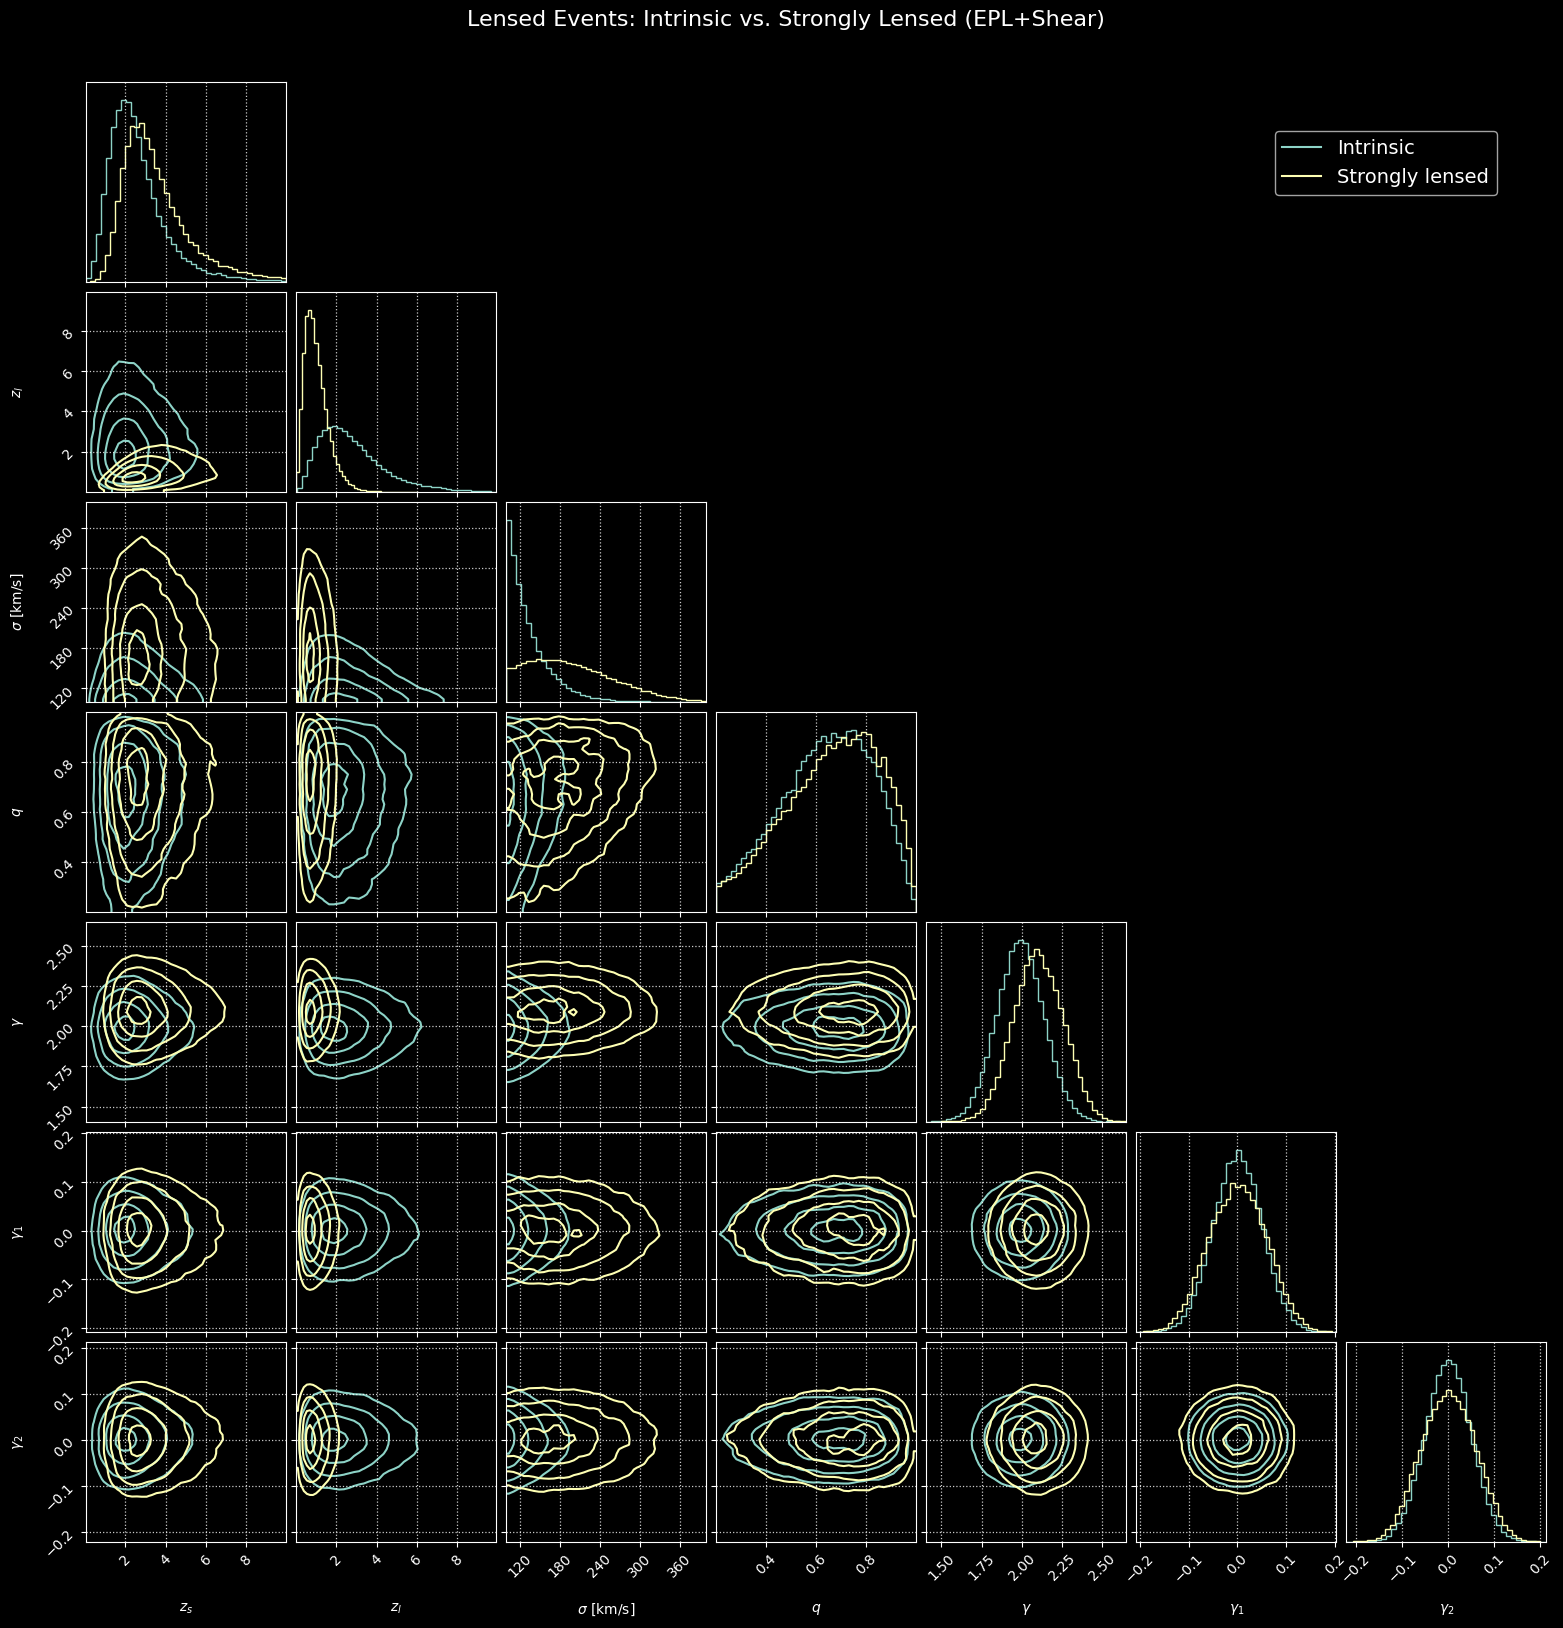

In [9]:
import corner
import matplotlib.lines as mlines

# Load data
param = lens_params
param_intrinsic = lens_params_int

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$', '$\gamma$', '$\gamma_1$', '$\gamma_2$']

# Prepare data for corner plot
samples_intrinsic = np.stack([param_intrinsic[p] for p in param_names], axis=1)
samples_all = np.stack([param[p] for p in param_names], axis=1)

fig = corner.corner(
    samples_intrinsic, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    bins=40,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples_all, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    bins=40,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True},
    fig=fig,
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='Intrinsic')
blue_line = mlines.Line2D([], [], color='C1', label='Strongly lensed')
leg = fig.legend(
    handles=[green_line, blue_line],
    loc='upper right',
    bbox_to_anchor=(0.95, 0.95),
    fontsize=14,
)

fig.suptitle(
    'Lensed Events: Intrinsic vs. Strongly Lensed (EPL+Shear)',
    fontsize=16,
    y=1.02,
)

plt.show()

## Compare with SIE and SIS

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ler.lens_galaxy_population import LensGalaxyParameterDistribution

ler_epl = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="epl_shear_galaxy",
    directory="../interpolator_json",
)

ler_sie = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    directory="../interpolator_json",
)

ler_sis = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sis_galaxy",
    directory="../interpolator_json",
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [2]:
# stronly lensed 
lens_params_epl = ler_epl.sample_lens_parameters(50000)
lens_params_sie = ler_sie.sample_lens_parameters(50000)
lens_params_sis = ler_sis.sample_lens_parameters(50000)

sampling lens parameters with epl_shear_sl_parameters_rvs...
sampling lens parameters with epl_shear_sl_parameters_rvs...
sampling lens parameters with epl_shear_sl_parameters_rvs...


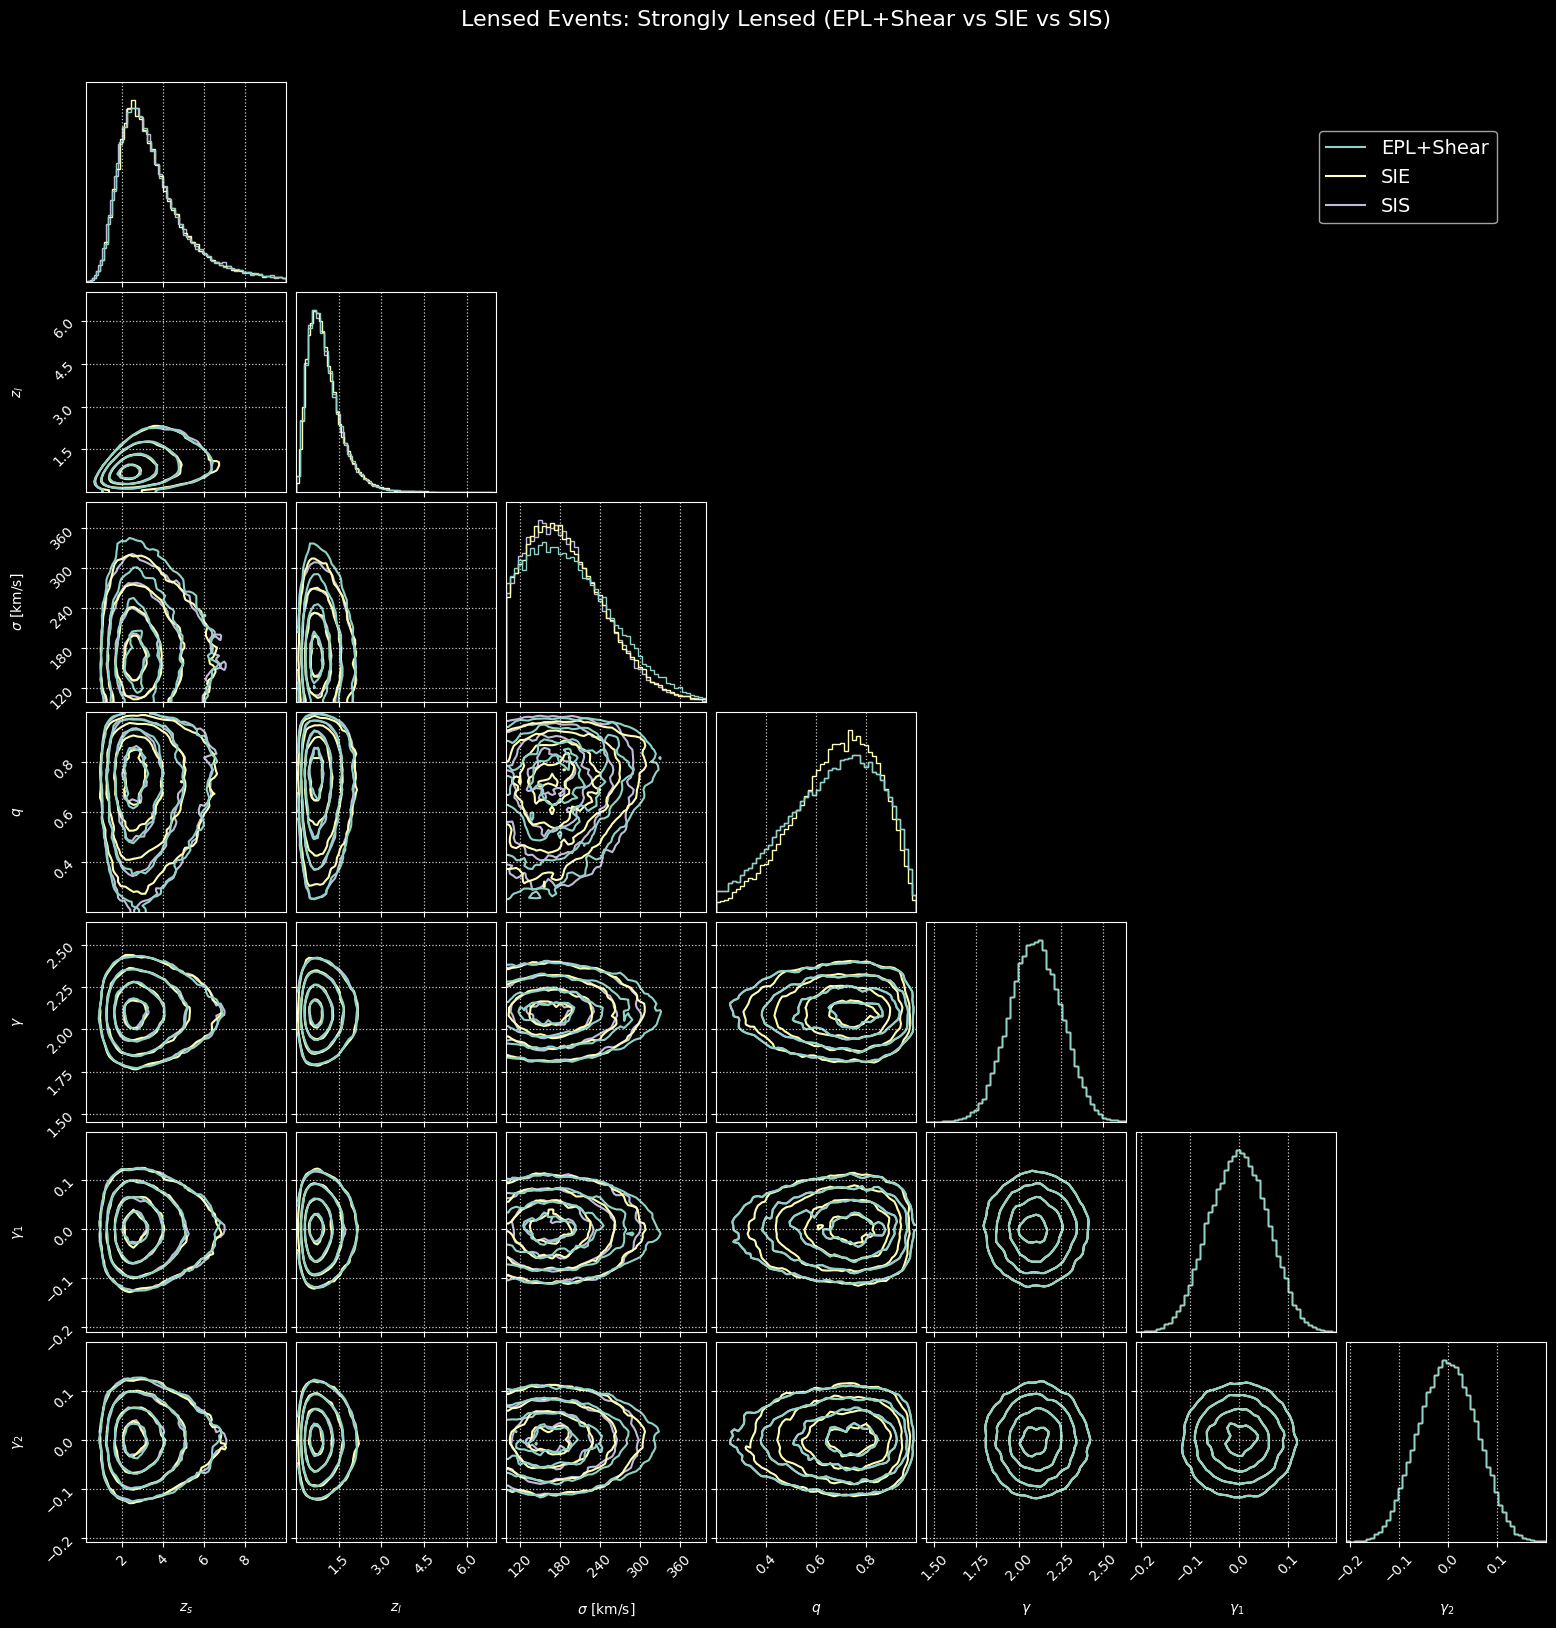

In [9]:
import corner
import matplotlib.lines as mlines

# Load data
param_epl = lens_params_epl
param_sie = lens_params_sie
param_sis = lens_params_sis

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$', '$\gamma$', '$\gamma_1$', '$\gamma_2$']

# Prepare data for corner plot
samples_epl = np.stack([param_epl[p] for p in param_names], axis=1)
samples_sie = np.stack([param_sie[p] for p in param_names], axis=1)
# replace 'gamma', 'gamma1', 'gamma2'
samples_sie[:, 4] = samples_epl[:, 4]
samples_sie[:, 5] = samples_epl[:, 5]
samples_sie[:, 6] = samples_epl[:, 6]
samples_sis = np.stack([param_sis[p] for p in param_names], axis=1)
# replace 'q', 'gamma', 'gamma1', 'gamma2'
samples_sis[:, 3] = samples_epl[:, 3]
samples_sis[:, 4] = samples_epl[:, 4]
samples_sis[:, 5] = samples_epl[:, 5]
samples_sis[:, 6] = samples_epl[:, 6]

# Create corner plot for intrinsic events
fig = corner.corner(
    samples_sis, 
    labels=labels, 
    color='C2', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples_sie, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples_epl, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='EPL+Shear')
blue_line = mlines.Line2D([], [], color='C1', label='SIE')
red_line = mlines.Line2D([], [], color='C2', label='SIS')
fig.legend(handles=[green_line, blue_line, red_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
fig.suptitle('Lensed Events: Strongly Lensed (EPL+Shear vs SIE vs SIS)', fontsize=16, y=1.02)

plt.show()


## Compare optical depths

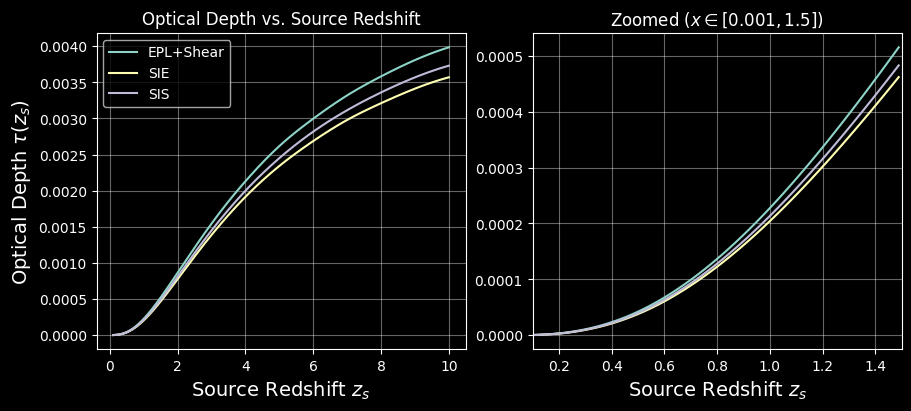

In [10]:
import numpy as np
import matplotlib.pyplot as plt

zs = np.linspace(0.1, 10.0, 500)
tau_epl = ler_epl.optical_depth(zs)
tau_sie = ler_sie.optical_depth(zs)
tau_sis = ler_sis.optical_depth(zs)

# plot + side plot (zoomed in x)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

# Main plot
ax1.plot(zs, tau_epl, label='EPL+Shear', color='C0')
ax1.plot(zs, tau_sie, label='SIE', color='C1')
ax1.plot(zs, tau_sis, label='SIS', color='C2')
ax1.set_xlabel('Source Redshift $z_s$', fontsize=14)
ax1.set_ylabel('Optical Depth $\\tau(z_s)$', fontsize=14)
ax1.set_title('Optical Depth vs. Source Redshift', fontsize=12)
ax1.grid(alpha=0.4)
ax1.legend(fontsize=10)

# Side plot (x-zoom)
idx = (zs >= 0.1) & (zs <= 1.5)
ax2.plot(zs[idx], tau_epl[idx], color='C0')
ax2.plot(zs[idx], tau_sie[idx], color='C1')
ax2.plot(zs[idx], tau_sis[idx], color='C2')
ax2.set_xlim(0.1, 1.5)
ax2.set_xlabel('Source Redshift $z_s$', fontsize=14)
ax2.set_title('Zoomed ($x \\in [0.001, 1.5]$)', fontsize=12)
ax2.grid(alpha=0.4)

plt.show()


## Intrinsic Merger Rate

In [ ]:
Rzs_epl = ler_epl.normalization_pdf_z_lensed
Rzs_sie = ler_sie.normalization_pdf_z_lensed
Rzs_sis = ler_sis.normalization_pdf_z_lensed
# unlensed 
Rzs_unlensed = ler_epl.normalization_pdf_z

# print
print(rf"R(z_s) (unlensed) = {Rzs_unlensed:.2e}")
print(rf"R(z_s) (EPL+Shear) = {Rzs_epl:.2e}, ratio = {Rzs_epl/Rzs_unlensed:.2e}")
print(rf"R(z_s) (SIE) = {Rzs_sie:.2e}, ratio = {Rzs_sie/Rzs_unlensed:.2e}")
print(rf"R(z_s) (SIS) = {Rzs_sis:.2e}, ratio = {Rzs_sis/Rzs_unlensed:.2e}")

R(z_s) (unlensed) = 9.16e+04
R(z_s) (EPL+Shear) = 1.12e+02, ratio = 1.22e-03
R(z_s) (SIE) = 1.00e+02, ratio = 1.09e-03
R(z_s) (SIS) = 1.05e+02, ratio = 1.14e-03
